In [1]:
import numpy as np
from boed.core import make_u0
from boed.priors.kernels import Gaussian, Matern12, Matern32, Matern52
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel
from boed.pde.advection_diffusion import AdvectionDiffusion1D_CN
from boed.viz.boed_visualizer_pro import BOEDVisualizerPro
from boed.inference import LinearGaussianModel
from boed.observations.sensors import SpaceTimeSensors
from boed.core.utils import build_selection_matrices
import matplotlib.pyplot as plt 
from boed.design.criteria import DesignCriteria
from boed.design.greedy import run_greedy_oed_LG

SEED = 42
np.random.seed(SEED)

In [2]:
# ===============================================================================
# PARAMETERS
# ===============================================================================
N = 200
dt = 0.0005
n_steps = 200
diffusivity = 0.01
velocity = 0.5

In [3]:
model = AdvectionDiffusion1D_CN(N=N, dt=dt, diffusivity=diffusivity, velocity=velocity)
x_grid = np.linspace(0,1,N)

In [4]:
# ------------------- Prior -------------------
kernel = Matern52(length_scale=1., sigma=1.5)
prior_process = GaussianProcessPrior(kernel, nx=N, mu=None)
Sigma_prior = prior_process.Sigma
mu_prior = prior_process.mu
x_prior = prior_process.x


(201, 200)


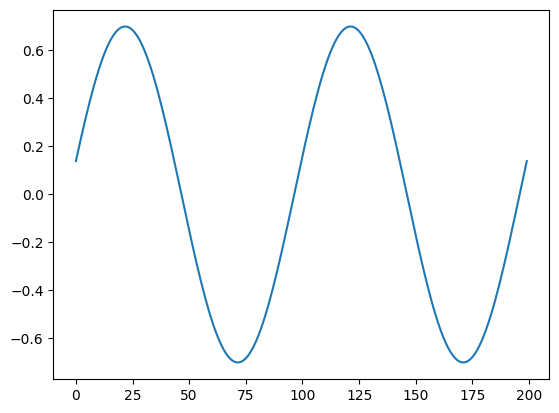

In [5]:
# ------------------- Synthetic data -------------------
u_true = make_u0(
    x_grid,
    "sine",
)
trajectory = model.evolve(u_true, n_steps)
plt.plot(u_true)
print(trajectory.shape)

In [6]:
noise = NoiseModel(sigma_noise=0.01)
epsilon = noise.sample(N, n_samples=n_steps+1).T  # shape matches trajectory
y_obs = trajectory + epsilon.T
Sigma_noise = noise.get_covariance(N)

In [7]:
# --- Reconstruction de u0 (Condition Initiale) ---
lgm = LinearGaussianModel(model = model, n_steps = n_steps, Sigma_obs = Sigma_noise, mu_prior = mu_prior, Sigma_prior = Sigma_prior)
np.random.seed(42)
random_indices = np.random.choice(np.arange(N), 10, replace=False)

print(random_indices)
W, _ = build_selection_matrices(n_obs=N, active_indices=random_indices)

mu_post, Sigma_post = lgm.posterior(y_obs[n_steps], W=W)
print(f"EIG kl : {DesignCriteria.EIG(Sigma_post=Sigma_post, Sigma_prior=Sigma_prior)}")
print(f"EIG lgm : {lgm.expected_information_gain(W=W)}")
print(f"EIG obs : {DesignCriteria.eig_from_observation_cov(lgm.Sigma_Y(), Sigma_noise=Sigma_noise, W=W)}")
# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_post, Sigma_post,
    title="Reconstruction de la Condition Initiale (u0)",
    filename="reconstruction_u0.png"
)

[ 95  15  30 158 128 115  69 170 174  45]
EIG kl : 18.76897466192281
EIG lgm : 18.76897467878167
EIG obs : 18.76897467878167


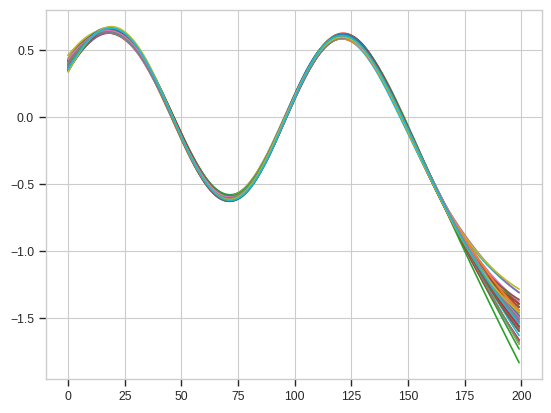

In [8]:
data = lgm.sample_posterior(mu_post, Sigma_post, n_samples=50)  # (50, n_params)
plt.plot(data.T)
plt.show()